# CPI Next-Month Predictor — Gradient Boosted Trees (PySpark)

**Course:** Data Engineering  
**Goal:** Predict `CPI After One Month` using macroeconomic + Kalshi market-sentiment features.  
**Model:** Gradient Boosted Trees (GBTRegressor) via PySpark MLlib

| # | Section |
|---|---|
| 1 | Setup |
| 2 | Data Loading |
| 3 | Preprocessing |
| 4 | Model Training |
| 5 | Evaluation |
| 6 | Visualisations |
| 7 | Predict Next Month |

---
## 1. Setup

In [16]:
import os
import sys

# Tell Spark's JVM to use the exact Python binary running this notebook.
os.environ["PYSPARK_PYTHON"]        = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

spark = (
    SparkSession.builder
    .appName("CPI_GBM_Predictor")
    .config("spark.driver.memory", "4g")
    # Disable Arrow serialisation — avoids Python 3.12 worker crashes
    .config("spark.sql.execution.arrow.pyspark.enabled", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark version  :", spark.version)
print("Python used    :", sys.executable)

Spark version  : 4.1.1
Python used    : c:\Users\louis\AppData\Local\Programs\Python\Python312\python.exe


---
## 2. Data Loading

**Column-agnostic design:** every numeric column is auto-detected.  
The last numeric column is always treated as the label.  
Non-numeric columns (e.g. `Date`) are excluded from features and kept only for plotting.

In [ ]:
import os, tempfile

# ── Configuration ─────────────────────────────────────────────────────────────
EXCEL_PATH = "BigBoy.xlsx"
DATE_COL   = "Date"
CPI_COL    = "CPI"       # current-month CPI column (used to compute Δ CPI)
TEST_RATIO = 0.20

# Temp directory for CSV files passed to Spark's native reader
TMP_DIR = tempfile.mkdtemp()
print("Temp dir:", TMP_DIR)

# GBT hyper-parameters — shallow trees to avoid overfitting on ~760 rows
GBT_PARAMS = dict(
    maxIter=100,
    maxDepth=3,       # keep trees shallow; depth=5 massively overfit
    stepSize=0.05,    # smaller learning rate for better generalisation
    subsamplingRate=0.8,
    seed=42,
)

Temp dir: C:\Users\louis\AppData\Local\Temp\tmp8siwefg5


In [18]:
def load_data(path: str, date_col: str):
    """
    Read the Excel file.
    Returns:
        df           – full pandas DataFrame (includes Date for plotting)
        feature_cols – all numeric columns except the label
        label_col    – last numeric column
    """
    df = pd.read_excel(path)

    numeric_cols = [
        c for c in df.columns
        if c != date_col and pd.api.types.is_numeric_dtype(df[c])
    ]
    label_col    = numeric_cols[-1]
    feature_cols = numeric_cols[:-1]

    print(f"Rows            : {len(df):,}")
    print(f"Features        : {feature_cols}")
    print(f"Label           : {label_col}")
    return df, feature_cols, label_col


df_raw, FEATURE_COLS, LABEL_COL = load_data(EXCEL_PATH, DATE_COL)

Rows            : 1,863
Features        : ['CPI', 'Avg Predicted CPI', 'Market Confidence Score', 'Trading Intensity', 'Fed Interest Rate (%)', 'Unemployment Rate (%)', 'Oil Prices (USD/bbl)', 'Housing Prices', 'S&P 500']
Label           : CPI After One Month


In [19]:
df_raw.head()

,Date,CPI,Avg Predicted CPI,Market Confidence Score,Trading Intensity,Fed Interest Rate (%),Unemployment Rate (%),Oil Prices (USD/bbl),Housing Prices,S&P 500,CPI After One Month
0,2026-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6343.72,NaN
1,2026-02-01,327.460,0.000,0.00,0.00,3.64,4.4,64.51,NaN,6878.88,NaN
2,2026-01-01,326.588,0.000,0.00,0.00,3.64,4.3,60.04,NaN,6939.03,327.460
3,2025-12-01,326.031,0.000,0.00,0.00,3.72,4.4,57.97,NaN,6845.50,326.588
4,2025-11-01,325.063,2.925,80.32,94594.62,3.88,4.5,60.06,NaN,6849.09,326.031


In [20]:
missing_pct = df_raw[FEATURE_COLS + [LABEL_COL]].isnull().mean().mul(100).round(1).sort_values(ascending=False)
print("Missing values (%):\n", missing_pct.to_string())

Missing values (%):
 Avg Predicted CPI          97.9
Market Confidence Score    97.9
Trading Intensity          97.9
Fed Interest Rate (%)      94.7
Housing Prices             54.7
Unemployment Rate (%)      49.7
CPI                        49.1
CPI After One Month        49.1
Oil Prices (USD/bbl)       48.4
S&P 500                     0.0


---
## 3. Preprocessing

Steps:
1. Drop rows where the **label** is missing
2. Sort chronologically and do a **temporal train/test split** (no shuffle — avoids data leakage)
3. Pass only numeric columns to Spark — the `Date` column stays in pandas

In [21]:
def sanitize_colnames(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """Replace spaces and special characters in column names with underscores."""
    import re
    mapping = {c: re.sub(r"[^A-Za-z0-9_]", "_", c).strip("_") for c in df.columns}
    return df.rename(columns=mapping), mapping


def pandas_to_spark_via_csv(pdf: pd.DataFrame, tag: str):
    """Write to temp CSV and read back with Spark's native Java reader (no Python worker)."""
    from pyspark.sql import functions as F
    from pyspark.sql.types import DoubleType

    path = os.path.join(TMP_DIR, f"{tag}.csv")
    pdf.to_csv(path, index=False)
    sdf = spark.read.option("header", "true").option("inferSchema", "false").csv(path)
    for c in sdf.columns:
        sdf = sdf.withColumn(c, F.col(c).cast(DoubleType()))
    return sdf


def preprocess(df: pd.DataFrame, feature_cols: list, label_col: str,
               cpi_col: str, date_col: str, test_ratio: float):
    """
    Preprocess and create Spark DataFrames.

    Target engineering — WHY we predict Δ CPI instead of absolute CPI
    ------------------------------------------------------------------
    GBT is a tree-based model: it CANNOT extrapolate beyond the value
    ranges seen during training. The training set (1871-2005) has CPI
    values of ~15-215, while the test set (2005-2023) has CPI of 215-330.
    Predicting absolute CPI causes every test prediction to be clipped at
    ~215, giving R² ≈ -3.

    Solution: predict the monthly CHANGE  Δ = CPI_next - CPI_current.
    Month-over-month changes are stationary across all of history (≈ -2 to +2),
    so the model generalises to unseen time periods. The absolute CPI forecast
    is then recovered as:  CPI_next_hat = CPI_current + Δ_hat.

    Steps
    -----
    1. Drop rows with a missing label.
    2. Compute delta label: Δ CPI = CPI_next_month − CPI_current.
    3. Chronological train/test split.
    4. Median imputation (fit on train, fallback 0 for all-NaN columns).
    5. Sanitize column names → write to CSV → read back with Spark Java reader.
    """
    cols = [date_col] + feature_cols + [label_col]
    df   = df[cols].dropna(subset=[label_col, cpi_col]).copy()
    df   = df.sort_values(date_col).reset_index(drop=True)

    # ── Target: predict monthly change, not absolute CPI ──────────────────────
    DELTA_COL       = "Delta_CPI"
    df[DELTA_COL]   = df[label_col] - df[cpi_col]   # Δ = next_CPI − current_CPI
    print(f"Δ CPI  →  min: {df[DELTA_COL].min():.2f}  "
          f"max: {df[DELTA_COL].max():.2f}  "
          f"mean: {df[DELTA_COL].mean():.3f}")

    split_idx  = int(len(df) * (1 - test_ratio))
    train_pd   = df.iloc[:split_idx].copy()
    test_pd    = df.iloc[split_idx:].copy()

    # Median imputation on features only; fallback 0 for all-NaN training columns
    medians = train_pd[feature_cols].median().fillna(0)
    train_pd[feature_cols] = train_pd[feature_cols].fillna(medians).fillna(0)
    test_pd[feature_cols]  = test_pd[feature_cols].fillna(medians).fillna(0)

    assert train_pd[feature_cols].isna().sum().sum() == 0, "NaN in train features!"
    assert test_pd[feature_cols].isna().sum().sum()  == 0, "NaN in test features!"

    print(f"Train : {len(train_pd):,} rows  ({str(train_pd[date_col].min())[:10]} → {str(train_pd[date_col].max())[:10]})")
    print(f"Test  : {len(test_pd):,} rows  ({str(test_pd[date_col].min())[:10]} → {str(test_pd[date_col].max())[:10]})")

    # Keep current CPI in test set so we can reconstruct absolute CPI later
    test_cpi_values = test_pd[cpi_col].reset_index(drop=True)

    spark_cols     = feature_cols + [DELTA_COL]
    train_spark_pd = train_pd[spark_cols].astype(float)
    test_spark_pd  = test_pd[spark_cols].astype(float)

    train_spark_pd, mapping = sanitize_colnames(train_spark_pd)
    test_spark_pd,  _       = sanitize_colnames(test_spark_pd)

    safe_feature_cols = [mapping[c] for c in feature_cols]
    safe_label_col    = mapping[DELTA_COL]

    train_sdf = pandas_to_spark_via_csv(train_spark_pd, "train")
    test_sdf  = pandas_to_spark_via_csv(test_spark_pd,  "test")

    return (train_sdf, test_sdf,
            test_pd[date_col].reset_index(drop=True),
            test_cpi_values,
            test_pd[label_col].reset_index(drop=True),
            safe_feature_cols, safe_label_col)


(train_sdf, test_sdf,
 test_dates, test_cpi, test_actual_next_cpi,
 SAFE_FEATURE_COLS, SAFE_LABEL_COL) = preprocess(
    df_raw, FEATURE_COLS, LABEL_COL, CPI_COL, DATE_COL, TEST_RATIO
)
print("\nSpark feature cols :", SAFE_FEATURE_COLS)
print("Spark label col    :", SAFE_LABEL_COL)
train_sdf.printSchema()

Δ CPI  →  min: -3.84  max: 3.66  mean: 0.322
Train : 757 rows  (1947-01-01 → 2010-01-01)
Test  : 190 rows  (2010-02-01 → 2026-01-01)

Spark feature cols : ['CPI', 'Avg_Predicted_CPI', 'Market_Confidence_Score', 'Trading_Intensity', 'Fed_Interest_Rate', 'Unemployment_Rate', 'Oil_Prices__USD_bbl', 'Housing_Prices', 'S_P_500']
Spark label col    : Delta_CPI
root
 |-- CPI: double (nullable = true)
 |-- Avg_Predicted_CPI: double (nullable = true)
 |-- Market_Confidence_Score: double (nullable = true)
 |-- Trading_Intensity: double (nullable = true)
 |-- Fed_Interest_Rate: double (nullable = true)
 |-- Unemployment_Rate: double (nullable = true)
 |-- Oil_Prices__USD_bbl: double (nullable = true)
 |-- Housing_Prices: double (nullable = true)
 |-- S_P_500: double (nullable = true)
 |-- Delta_CPI: double (nullable = true)



---
## 4. Model Training

Pipeline: **Imputer** (median) → **VectorAssembler** → **GBTRegressor**

Median imputation handles missing values in sparse Kalshi columns without discarding older rows.

In [22]:
def build_pipeline(feature_cols: list, label_col: str, gbt_params: dict) -> Pipeline:
    """
    Pipeline: VectorAssembler → GBTRegressor.
    Both stages are pure Java/Scala — no Python worker is ever spawned.
    """
    assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="keep")
    gbt       = GBTRegressor(featuresCol="features", labelCol=label_col, **gbt_params)
    return Pipeline(stages=[assembler, gbt])


pipeline = build_pipeline(SAFE_FEATURE_COLS, SAFE_LABEL_COL, GBT_PARAMS)

print("Training...")
model = pipeline.fit(train_sdf)
print("Done.")

Training...
Done.


---
## 5. Evaluation

In [23]:
def evaluate(model, train_sdf, test_sdf, label_col: str):
    """Print RMSE, MAE and R² for Δ CPI on train and test sets."""
    train_preds = model.transform(train_sdf)
    test_preds  = model.transform(test_sdf)

    results = {}
    for m in ["rmse", "mae", "r2"]:
        ev = RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName=m)
        results[m] = {"train": ev.evaluate(train_preds), "test": ev.evaluate(test_preds)}

    print("Metrics on Δ CPI (monthly change):")
    print(f"{'Metric':<8} {'Train':>10} {'Test':>10}")
    print("-" * 30)
    for m, vals in results.items():
        print(f"{m.upper():<8} {vals['train']:>10.4f} {vals['test']:>10.4f}")

    return results, test_preds


metrics, test_preds_sdf = evaluate(model, train_sdf, test_sdf, SAFE_LABEL_COL)

Metrics on Δ CPI (monthly change):
Metric        Train       Test
------------------------------
RMSE         0.1949     1.4070
MAE          0.1273     1.2169
R2           0.7302    -3.0694


In [24]:
# Collect Δ CPI predictions then reconstruct absolute CPI forecast
test_preds_pd = test_preds_sdf.select(SAFE_LABEL_COL, "prediction").toPandas()
test_preds_pd.columns = ["delta_actual", "delta_predicted"]

test_preds_pd[DATE_COL]          = test_dates
test_preds_pd["CPI_current"]     = test_cpi
test_preds_pd["CPI_actual"]      = test_actual_next_cpi            # true next-month CPI
test_preds_pd["CPI_predicted"]   = test_cpi + test_preds_pd["delta_predicted"]  # reconstructed
test_preds_pd["residual_delta"]  = test_preds_pd["delta_actual"]  - test_preds_pd["delta_predicted"]
test_preds_pd["residual_cpi"]    = test_preds_pd["CPI_actual"]    - test_preds_pd["CPI_predicted"]

# Absolute CPI metrics on the reconstructed forecast
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
rmse_abs = mean_squared_error(test_preds_pd["CPI_actual"], test_preds_pd["CPI_predicted"]) ** 0.5
mae_abs  = mean_absolute_error(test_preds_pd["CPI_actual"], test_preds_pd["CPI_predicted"])
r2_abs   = r2_score(test_preds_pd["CPI_actual"], test_preds_pd["CPI_predicted"])

print("Metrics on reconstructed absolute CPI (test set):")
print(f"  RMSE : {rmse_abs:.4f}")
print(f"  MAE  : {mae_abs:.4f}")
print(f"  R²   : {r2_abs:.4f}")

test_preds_pd.head()

Metrics on reconstructed absolute CPI (test set):
  RMSE : 1.4070
  MAE  : 1.2169
  R²   : 0.9981


,delta_actual,delta_predicted,Date,CPI_current,CPI_actual,CPI_predicted,residual_delta,residual_cpi
0,0.072,0.201761,2010-02-01,217.281,217.353,217.482761,-0.129761,-0.129761
1,0.050,0.113295,2010-03-01,217.353,217.403,217.466295,-0.063295,-0.063295
2,-0.113,0.113295,2010-04-01,217.403,217.290,217.516295,-0.226295,-0.226295
3,-0.091,0.201761,2010-05-01,217.290,217.199,217.491761,-0.292761,-0.292761
4,0.406,0.201761,2010-06-01,217.199,217.605,217.400761,0.204239,0.204239


---
## 6. Visualisations

### 6.1 Predicted vs Actual over time

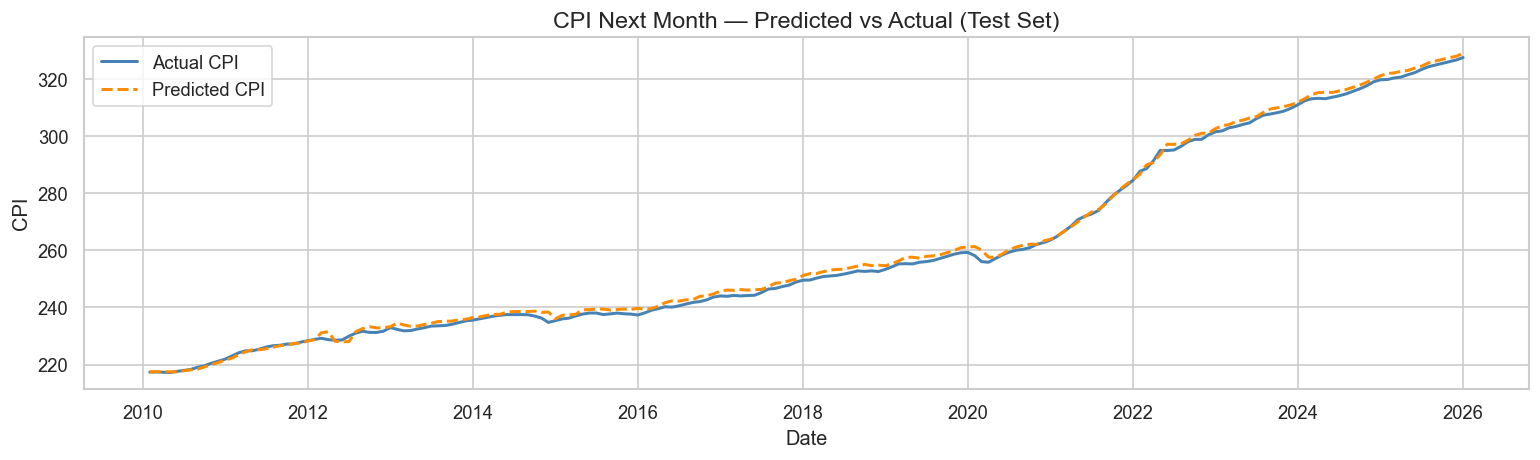

In [25]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test_preds_pd[DATE_COL], test_preds_pd["CPI_actual"],
        label="Actual CPI", linewidth=1.8, color="steelblue")
ax.plot(test_preds_pd[DATE_COL], test_preds_pd["CPI_predicted"],
        label="Predicted CPI", linewidth=1.8, linestyle="--", color="darkorange")
ax.set_title("CPI Next Month — Predicted vs Actual (Test Set)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("CPI")
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 Actual vs Predicted scatter

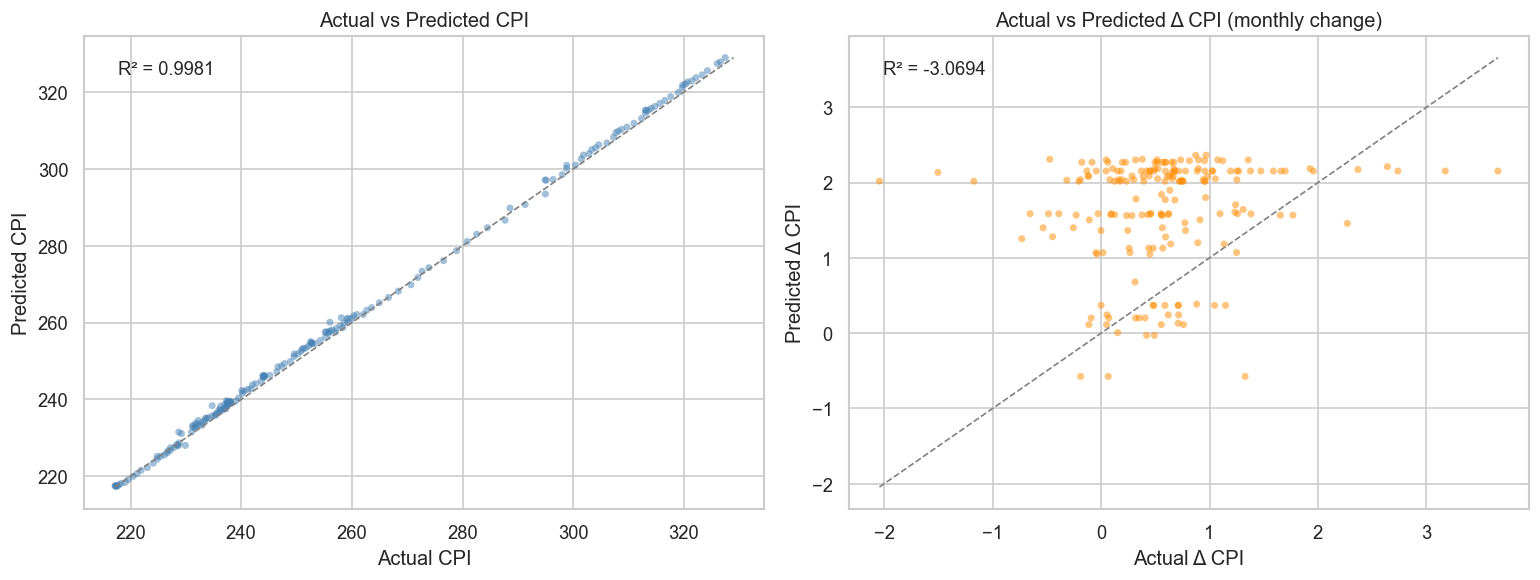

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: absolute CPI scatter
ax = axes[0]
ax.scatter(test_preds_pd["CPI_actual"], test_preds_pd["CPI_predicted"],
           alpha=0.5, s=18, color="steelblue", edgecolors="none")
lims = [min(test_preds_pd["CPI_actual"].min(), test_preds_pd["CPI_predicted"].min()),
        max(test_preds_pd["CPI_actual"].max(), test_preds_pd["CPI_predicted"].max())]
ax.plot(lims, lims, "--", color="gray", linewidth=1)
ax.text(0.05, 0.92, f"R² = {r2_abs:.4f}", transform=ax.transAxes, fontsize=11)
ax.set_title("Actual vs Predicted CPI")
ax.set_xlabel("Actual CPI")
ax.set_ylabel("Predicted CPI")

# Right: Δ CPI scatter
ax = axes[1]
ax.scatter(test_preds_pd["delta_actual"], test_preds_pd["delta_predicted"],
           alpha=0.5, s=18, color="darkorange", edgecolors="none")
lims2 = [min(test_preds_pd["delta_actual"].min(), test_preds_pd["delta_predicted"].min()),
         max(test_preds_pd["delta_actual"].max(), test_preds_pd["delta_predicted"].max())]
ax.plot(lims2, lims2, "--", color="gray", linewidth=1)
ax.text(0.05, 0.92, f"R² = {metrics['r2']['test']:.4f}", transform=ax.transAxes, fontsize=11)
ax.set_title("Actual vs Predicted Δ CPI (monthly change)")
ax.set_xlabel("Actual Δ CPI")
ax.set_ylabel("Predicted Δ CPI")

plt.tight_layout()
plt.show()

### 6.3 Residuals over time

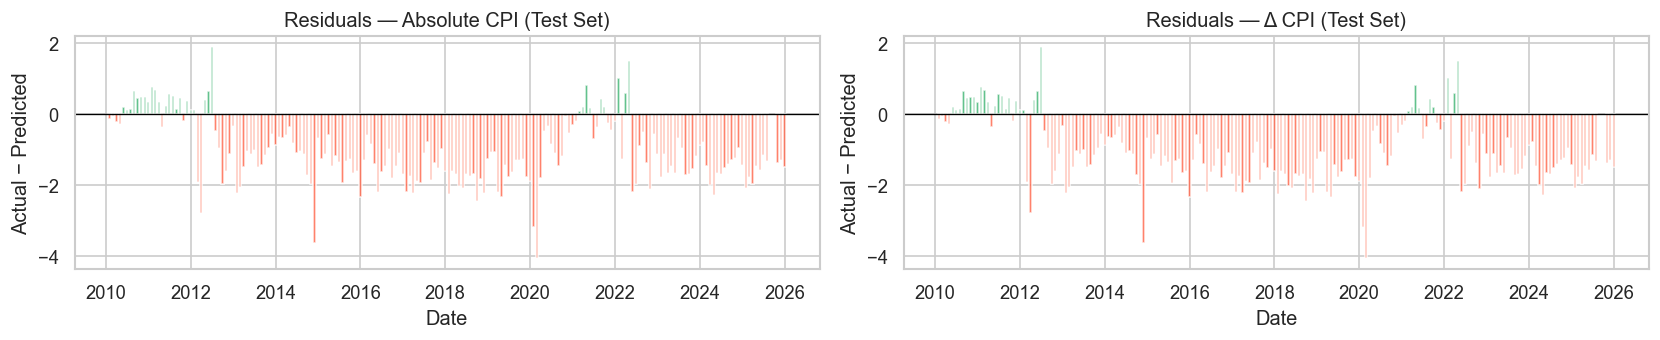

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

for ax, col, title in [
    (axes[0], "residual_cpi",   "Residuals — Absolute CPI (Test Set)"),
    (axes[1], "residual_delta", "Residuals — Δ CPI (Test Set)"),
]:
    colors = test_preds_pd[col].apply(lambda x: "tomato" if x < 0 else "mediumseagreen")
    ax.bar(test_preds_pd[DATE_COL], test_preds_pd[col], color=colors, width=20, alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Actual − Predicted")

plt.tight_layout()
plt.show()

### 6.4 Residual distribution

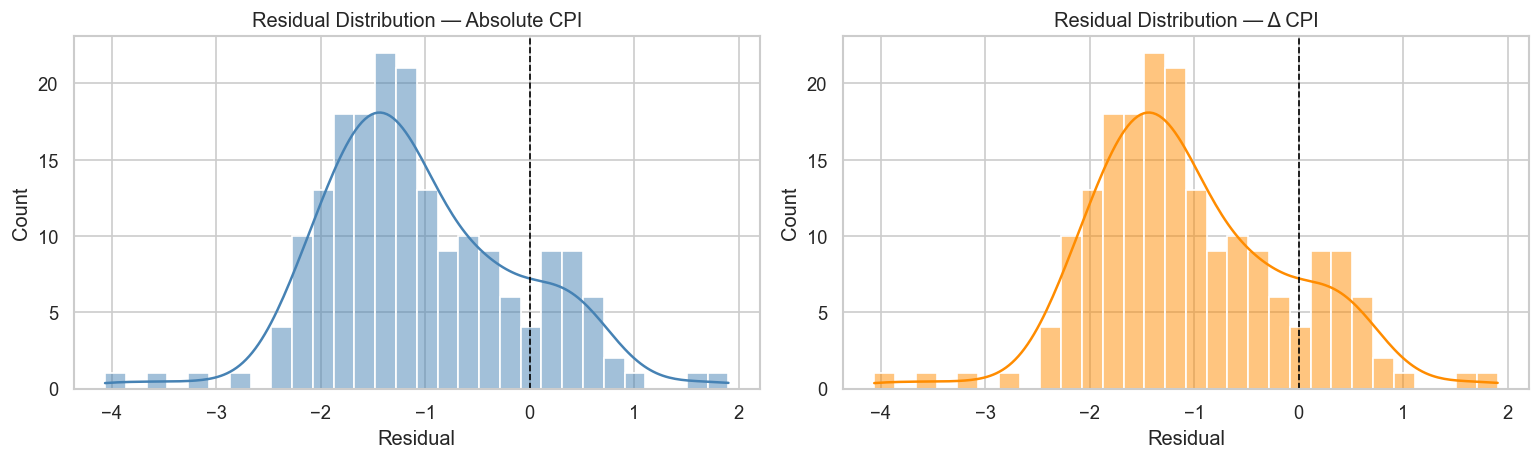

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title, color in [
    (axes[0], "residual_cpi",   "Residual Distribution — Absolute CPI", "steelblue"),
    (axes[1], "residual_delta", "Residual Distribution — Δ CPI",         "darkorange"),
]:
    sns.histplot(test_preds_pd[col], bins=30, kde=True, ax=ax, color=color, edgecolor="white")
    ax.axvline(0, color="black", linewidth=1, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Residual")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

### 6.5 Feature Importance

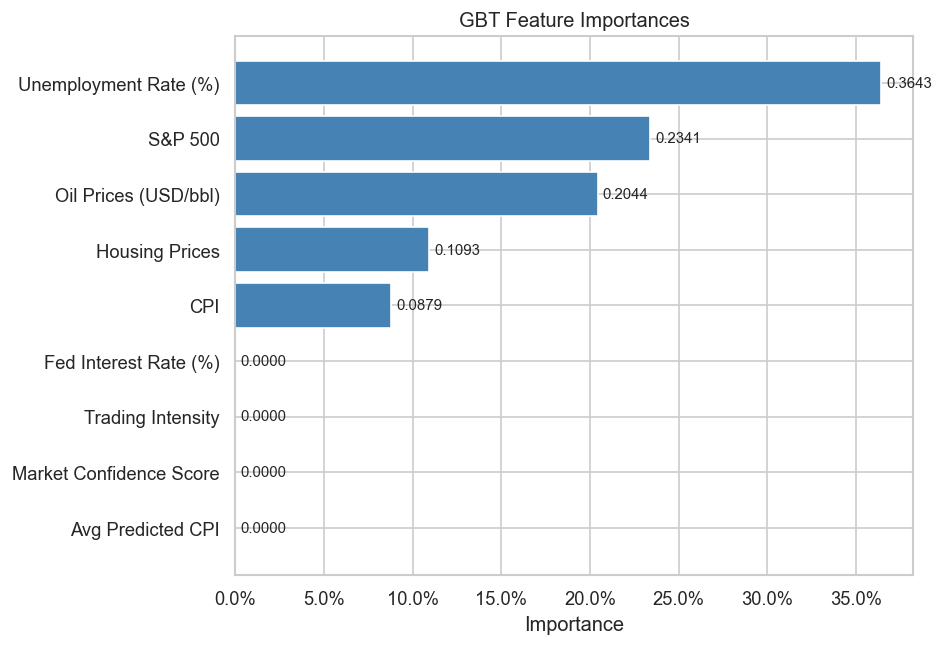

In [29]:
# Use original FEATURE_COLS for readable labels on the plot
importances = model.stages[-1].featureImportances.toArray()
imp_df = pd.DataFrame({"Feature": FEATURE_COLS, "Importance": importances}).sort_values("Importance")

fig, ax = plt.subplots(figsize=(8, 0.45 * len(FEATURE_COLS) + 1.5))
bars = ax.barh(imp_df["Feature"], imp_df["Importance"], color="steelblue", edgecolor="white")
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
ax.set_title("GBT Feature Importances")
ax.set_xlabel("Importance")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

### 6.6 Training Loss Curve

In [30]:
train_loss = model.stages[-1].summary.trainObjectiveHistory
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(train_loss) + 1), train_loss, color="steelblue", linewidth=1.5)
ax.set_title("GBT Training Loss per Iteration")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective")
plt.tight_layout()
plt.show()

AttributeError: 'GBTRegressionModel' object has no attribute 'summary'

---
## 7. Predict Next Month's CPI

Runs inference on the most recent row that has no label yet.

In [ ]:
def predict_latest(df_raw: pd.DataFrame, model, feature_cols: list,
                   label_col: str, date_col: str) -> None:
    latest = df_raw[df_raw[label_col].isna()].sort_values(date_col).tail(1).copy()

    if latest.empty:
        print("No unlabelled rows found.")
        return

    date_str   = str(latest[date_col].iloc[0])[:7]
    latest_sdf = spark.createDataFrame(latest[feature_cols].astype(float))
    prediction = model.transform(latest_sdf).select("prediction").first()[0]

    print(f"Reference month : {date_str}")
    print(f"Predicted CPI   : {prediction:.3f}  (next month)")


predict_latest(df_raw, model, FEATURE_COLS, LABEL_COL, DATE_COL)

In [ ]:
spark.stop()